In [1]:
# ==========================================
# IMPORT LIBRARY
# ==========================================

import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Penyeimbangan Data
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Menyimpan Model
import joblib

# Menghilangkan warning
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Tb rawat inap.csv", sep=";")

print("Jumlah Data Awal")
print(df.shape)
print(df.head())

Jumlah Data Awal
(4026, 8)
   Umur Jenis Kelamin Sesak Nafas    Batuk    Demam Mual Muntah  \
0    63             L       Tidak   3 Hari   36.2 C       Tidak   
1    63             L       Tidak   7 Hari   36.5 C       Tidak   
2     8             L       Tidak   5 Hari  37.5 C        Tidak   
3    47             P          Ya  30 Hari   36.0 C       Tidak   
4    55             P          Ya  15 Hari   36.1 C       Tidak   

  Penyakit Bawaan TB Paru  
0              Ya   Tidak  
1              Ya   Tidak  
2           Tidak   Tidak  
3           Tidak      Ya  
4           Tidak      Ya  


In [3]:
df["Batuk"] = df["Batuk"].replace({
    "Tidak": "0 Hari",
    "Ya": "14 Hari",
    
})

df["Batuk"] = (
    df["Batuk"]
    .str.replace("Hari", "", regex=False)
    .str.strip()
    .astype(int)
)

In [4]:
# ==========================================
# INFORMASI DATASET
# ==========================================

print("\nInformasi Dataset")
print(df.info())


Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4026 entries, 0 to 4025
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Umur             4026 non-null   int64 
 1   Jenis Kelamin    4026 non-null   object
 2   Sesak Nafas      4026 non-null   object
 3   Batuk            4026 non-null   int64 
 4   Demam            4026 non-null   object
 5   Mual Muntah      4026 non-null   object
 6   Penyakit Bawaan  4026 non-null   object
 7   TB Paru          4026 non-null   object
dtypes: int64(2), object(6)
memory usage: 251.8+ KB
None


In [5]:
# ==========================================
# CEK MISSING VALUE
# ==========================================

print("\nMissing Value")
print(df.isnull().sum())


Missing Value
Umur               0
Jenis Kelamin      0
Sesak Nafas        0
Batuk              0
Demam              0
Mual Muntah        0
Penyakit Bawaan    0
TB Paru            0
dtype: int64


In [6]:
# ==========================================
# DISTRIBUSI TARGET
# ==========================================

print("\nDistribusi TB Paru")
print(df['TB Paru'].value_counts())


Distribusi TB Paru
TB Paru
Tidak    2758
Ya       1268
Name: count, dtype: int64


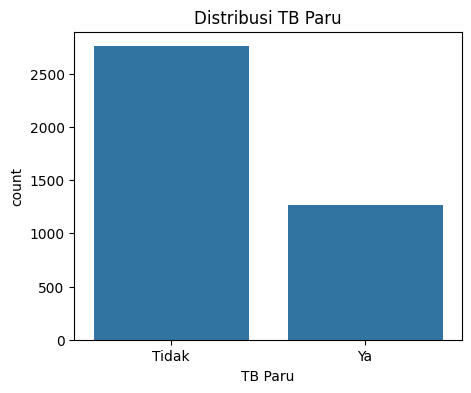

In [7]:
plt.figure(figsize=(5,4))

sns.countplot(data=df, x='TB Paru')

plt.title("Distribusi TB Paru")
plt.show()

In [8]:
# ==========================================
# CEK DUPLIKAT
# ==========================================

print("\nJumlah Data Duplikat :", df.duplicated().sum())


Jumlah Data Duplikat : 2917


In [9]:
# ==========================
# Encoding Jenis Kelamin
# ==========================
df["Jenis Kelamin"] = df["Jenis Kelamin"].map({
    "L": 1,
    "P": 0
})

# ==========================
# Encoding Ya/Tidak
# ==========================
kolom_ya_tidak = [
    "Sesak Nafas",
    "Mual Muntah",
    "Penyakit Bawaan",
    "TB Paru"
]

for kolom in kolom_ya_tidak:
    df[kolom] = df[kolom].map({
        "Ya": 1,
        "Tidak": 0
    })

In [10]:
# ==========================================
# CEK HASIL ENCODING
# ==========================================

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4026 entries, 0 to 4025
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Umur             4026 non-null   int64 
 1   Jenis Kelamin    4026 non-null   int64 
 2   Sesak Nafas      4026 non-null   int64 
 3   Batuk            4026 non-null   int64 
 4   Demam            4026 non-null   object
 5   Mual Muntah      4026 non-null   int64 
 6   Penyakit Bawaan  4026 non-null   int64 
 7   TB Paru          4026 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 251.8+ KB
None
   Umur  Jenis Kelamin  Sesak Nafas  Batuk    Demam  Mual Muntah  \
0    63              1            0      3   36.2 C            0   
1    63              1            0      7   36.5 C            0   
2     8              1            0      5  37.5 C             0   
3    47              0            1     30   36.0 C            0   
4    55              0            1     15   36

In [11]:
df["Demam"] = (
    df["Demam"]
    .astype(str)
    .str.replace("C", "", regex=False)
    .str.strip()
)

# Ganti nilai yang bukan angka menjadi NaN
df["Demam"] = pd.to_numeric(df["Demam"], errors="coerce")

# Isi NaN dengan suhu normal (atau median)
df["Demam"] = df["Demam"].fillna(36.5)

In [12]:
# Hilangkan huruf C dan spasi
df["Demam"] = (
    df["Demam"]
    .astype(str)
    .str.replace("C", "", regex=False)
    .str.strip()
)

# Ubah menjadi float
df["Demam"] = pd.to_numeric(df["Demam"], errors="coerce")

In [13]:
# ==========================================
# MEMISAHKAN FITUR DAN TARGET
# ==========================================

X = df.drop('TB Paru', axis=1)
y = df['TB Paru']

print("Jumlah Fitur :", X.shape)
print("Jumlah Target :", y.shape)

Jumlah Fitur : (4026, 7)
Jumlah Target : (4026,)


In [14]:
# ==========================================
# MEMBAGI DATA TRAIN DAN TEST
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Testing :", X_test.shape)

Data Training : (3220, 7)
Data Testing : (806, 7)


In [15]:
# ==========================================
# ADASYN (Oversampling)
# ==========================================
adasyn = ADASYN(random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(
    X_train,
    y_train
)

print("Jumlah Data Setelah ADASYN")
print(pd.Series(y_train_adasyn).value_counts())

Jumlah Data Setelah ADASYN
TB Paru
0    2206
1    2177
Name: count, dtype: int64


In [16]:
# ==========================================
# TOMEK LINKS (Undersampling)
# ==========================================

tomek = TomekLinks()

X_train_balanced, y_train_balanced = tomek.fit_resample(
    X_train_adasyn,
    y_train_adasyn
)

print("\nJumlah Data Setelah Tomek Links")
print(pd.Series(y_train_balanced).value_counts())


Jumlah Data Setelah Tomek Links
TB Paru
0    2202
1    2177
Name: count, dtype: int64


In [17]:
# ==========================================
# RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [18]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [19]:
# ==========================================
# GRID SEARCH CV
# ==========================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    X_train_balanced,
    y_train_balanced
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

In [20]:
print("Parameter Terbaik")
print(grid_search.best_params_)

print("\nAkurasi Cross Validation")
print(grid_search.best_score_)

Parameter Terbaik
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Akurasi Cross Validation
0.909794390084801


In [21]:
# ==========================================
# MODEL TERBAIK
# ==========================================

best_rf = grid_search.best_estimator_

print(best_rf)

RandomForestClassifier(max_depth=20, n_jobs=-1, random_state=42)


In [22]:
# ==========================================
# PREDIKSI DATA TESTING
# ==========================================

y_pred = best_rf.predict(X_test)

In [23]:
# ==========================================
# EVALUASI MODEL
# ==========================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 0.9193548387096774
Precision: 0.8411552346570397
Recall   : 0.9173228346456693
F1 Score : 0.8775894538606404


In [24]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       552
           1       0.84      0.92      0.88       254

    accuracy                           0.92       806
   macro avg       0.90      0.92      0.91       806
weighted avg       0.92      0.92      0.92       806



In [25]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[508  44]
 [ 21 233]]


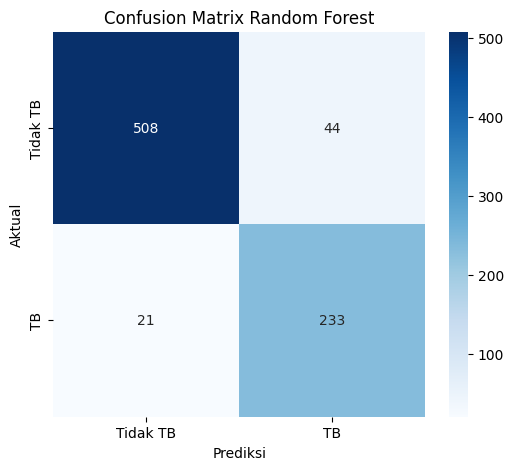

In [26]:
# ==========================================
# VISUALISASI CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak TB','TB'],
    yticklabels=['Tidak TB','TB']
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Random Forest")

plt.show()

In [27]:
# ==========================================
# CROSS VALIDATION
# ==========================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_score = cross_val_score(
    best_rf,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Cross Validation Score")
print(cv_score)

print("Rata-rata Accuracy")
print(cv_score.mean())

Cross Validation Score
[0.96277916 0.96770186 0.96024845 0.95900621 0.96397516]
Rata-rata Accuracy
0.9627421666692353


In [28]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

             Fitur  Importance
2      Sesak Nafas    0.632146
0             Umur    0.296492
6  Penyakit Bawaan    0.034565
3            Batuk    0.016781
1    Jenis Kelamin    0.012808
5      Mual Muntah    0.005072
4            Demam    0.002137


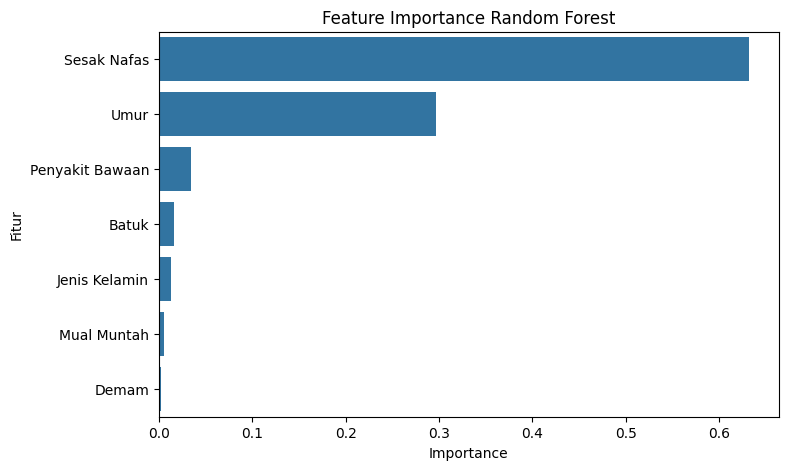

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Fitur'
)

plt.title("Feature Importance Random Forest")

plt.show()

In [30]:
joblib.dump(best_rf, "model_tb_paru.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!
